In [27]:
import numpy as np
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList
from sklearn.metrics import roc_curve, roc_auc_score, auc

## (1) Do this for one job. 

Quite simple: how can I just compute the AUC and tpr at low FPR for just one job? 

In [28]:
def compute_performance(scores_members, scores_non_members):
    mia_performance = {}
    
    member_vals = [val for val in scores_members]
    non_member_vals = [val for val in scores_non_members]
    mia_performance['auc'] = roc_auc_score([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    fpr, tpr, thresholds = roc_curve([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    for target_fpr in (0.01, 0.05, 0.1):
        mia_performance[f'tpr_at_{target_fpr}'] = np.interp(target_fpr, fpr, tpr)
    print(f"AUC: {mia_performance['auc']}, TPR@0.01: {mia_performance['tpr_at_0.01']}, TPR@0.05: {mia_performance['tpr_at_0.05']}, TPR@0.1: {mia_performance['tpr_at_0.1']}")

    # also add the curves
    mia_performance['fpr'] = fpr
    mia_performance['tpr'] = tpr

    return mia_performance

In [29]:
# paste the url of the (completed) target job here

jobs = JobList.from_urls([
    'https://ml.azure.com/runs/calm_honey_k70j459lks?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#'])

In [30]:
# download the corresponding scores and challenge bits
# Note that this faisl when the target directory already exists, so always use a new name for each job (or remove the old results)

job_name = 'JOB_NAME'
test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')

In [31]:
scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
scores[0], bits[0]

({'score': 1.0657628449776577}, {'challenge_bit': 1})

AUC: 0.574856671907694, TPR@0.01: 0.021696252465483234, TPR@0.05: 0.09664694280078895, TPR@0.1: 0.14792899408284024


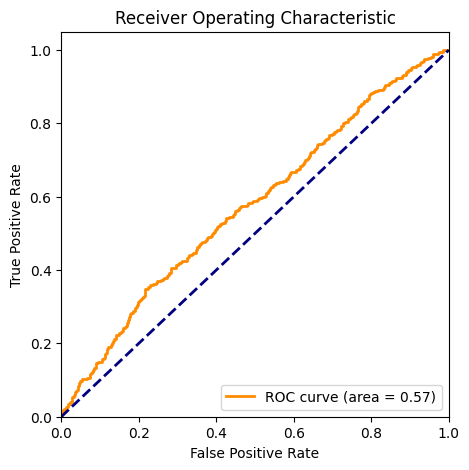

In [32]:
membership_scores = np.array([k['score'] for k in scores])
membership_labels = np.array([k['challenge_bit'] for k in bits])
members = membership_scores[membership_labels == 1]
non_members = membership_scores[membership_labels == 0]

# compute performance
performance = compute_performance(members, non_members)

fpr, tpr = performance['fpr'], performance['tpr']
roc_auc = performance['auc']

# Plot ROC curve
plt.figure(figsize = (5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [30]:
# let's also make a function that computes the performance directly from the url

from datetime import datetime

def compute_performance_from_url(url, job_name = None):
    jobs = JobList.from_urls([url])
    if job_name is None:
        job_name = str(datetime.now())
    
    if not os.path.exists(f'./mia_results/{job_name}'):
        test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
        test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')
    scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
    bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
    
    membership_scores = np.array([k['score'] for k in scores])
    membership_labels = np.array([k['challenge_bit'] for k in bits])
    members = membership_scores[membership_labels == 1]
    non_members = membership_scores[membership_labels == 0]
    return compute_performance(members, non_members)

performance = compute_performance_from_url('https://ml.azure.com/runs/calm_honey_k70j459lks?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#')

AUC: 0.574856671907694, TPR@0.01: 0.021696252465483234, TPR@0.05: 0.09664694280078895, TPR@0.1: 0.14792899408284024


## (2) Do this across jobs submitted using a bash script

I just launched a series of jobs using a bash script and I wrote the job output to a txt file. How can I easily compute the MIA performance for all results? 

For for the main experiment I ran

`./scripts/launch_no_synthetic_main_experiment.sh > job_launch_outputs/no_synthetic_main_exp.txt`. Let's get these results. 

In [31]:
import re

def extract_aml_urls(log_file_path):
    # Initialize a list to store the extracted URLs
    aml_urls = []

    # Define a regular expression to match the log entries containing AML URLs
    aml_url_pattern = re.compile(r'AML URL: (https://ml\.azure\.com/runs/[\w\-\?&=/]+)')

    # Open and read the log file
    with open(log_file_path, 'r') as file:
        for line in file:
            match = aml_url_pattern.search(line)
            if match:
                aml_urls.append(match.group(1))

    return aml_urls

# Extract the AML URLs
aml_urls = extract_aml_urls('../job_launch_outputs/no_synthetic_main_exp.txt')
aml_urls

['https://ml.azure.com/runs/amiable_roof_qs9w099y2f?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/gentle_tail_0bfkrfjv50?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/hungry_berry_n7nzm04r84?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/blue_whale_w9k49kxdvn?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/clever_knot_1htrpfxl9n?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af

In [32]:
# list the canary methods in the same order as you did when submitting the jobs

canary_methods=("no_synthetic_sst2_syntheticcanary_canarylabel", "no_synthetic_sst2_syntheticcanary_uniformlabel",
                "no_synthetic_sst2_incanary", "no_synthetic_agnews_syntheticcanary_canarylabel",
                "no_synthetic_agnews_syntheticcanary_uniformlabel", "no_synthetic_agnews_incanary")

assert len(aml_urls) == len(canary_methods)

In [7]:
# now run through it all 

all_aucs, all_tpr_001, all_tpr_01 = [], [], []

for i, url in enumerate(aml_urls):
    job_name = f'main_exp_no_synthetic_{canary_methods[i]}'
    print(f"Processing {job_name}")
    performance = compute_performance_from_url(url, job_name=job_name)
    all_aucs.append(performance['auc'])
    all_tpr_001.append(performance['tpr_at_0.01'])
    all_tpr_01.append(performance['tpr_at_0.1'])

Processing main_exp_no_synthetic_no_synthetic_sst2_syntheticcanary_canarylabel
AUC: 0.9990158070981913, TPR@0.01: 0.9684418145956607, TPR@0.05: 0.9960552268244576, TPR@0.1: 1.0
Processing main_exp_no_synthetic_no_synthetic_sst2_syntheticcanary_uniformlabel
AUC: 0.9986597373085124, TPR@0.01: 0.9723865877712031, TPR@0.05: 0.9940828402366864, TPR@0.1: 0.9960552268244576
Processing main_exp_no_synthetic_no_synthetic_sst2_incanary
AUC: 0.9108965357210014, TPR@0.01: 0.14765285996055227, TPR@0.05: 0.5976331360946746, TPR@0.1: 0.7954635108481262
Processing main_exp_no_synthetic_no_synthetic_agnews_syntheticcanary_canarylabel
AUC: 0.9992318494424908, TPR@0.01: 0.9901380670611439, TPR@0.05: 0.9960552268244576, TPR@0.1: 0.9960552268244576
Processing main_exp_no_synthetic_no_synthetic_agnews_syntheticcanary_uniformlabel
AUC: 0.9963592864201383, TPR@0.01: 0.9546351084812623, TPR@0.05: 0.9763313609467456, TPR@0.1: 0.9901380670611439
Processing main_exp_no_synthetic_no_synthetic_agnews_incanary
AUC: 

Let's also do this for the synthetic experiment. 

Here I launched `./scripts/launch_all_synthetic_mias_main_experiment.sh > job_launch_outputs/all_synthetic_main_exp.txt`, for all the synthetic attacks in the main experiment. So let's go. 

In [33]:
# list the MIA methods in the same order as you did when submitting the jobs

canary_methods=("synthetic_sst2_syntheticcanary_canarylabel", "synthetic_sst2_syntheticcanary_uniformlabel",
         "synthetic_sst2_incanary", "synthetic_agnews_syntheticcanary_canarylabel",
         "synthetic_agnews_syntheticcanary_uniformlabel", "synthetic_agnews_incanary")

# Define the array of mia_method values
mia_methods=("jaccard_25", "embedding_25", "ngram_2")

aml_urls = extract_aml_urls('../job_launch_outputs/all_synthetic_main_exp.txt')
assert len(aml_urls) == len(mia_methods) * len(canary_methods)
aml_urls

['https://ml.azure.com/runs/hungry_chain_84kdzrh6wm?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/sharp_owl_xfz8zdp9w1?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/red_chayote_dpb97qxp4b?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/amusing_grape_jb9glq5l7c?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/tidy_shelf_q5r6tfffyp?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-

In [34]:
# now run through it all 

all_aucs, all_tpr_001, all_tpr_01 = [], [], []

i = 0

for canary_method in canary_methods:
    for mia_method in mia_methods:
        url = aml_urls[i]
        job_name = f'main_exp_all_synthetic_{canary_method}_{mia_method}'
        print(f"Processing {job_name}")
        performance = compute_performance_from_url(url, job_name=job_name)
        all_aucs.append(performance['auc'])
        all_tpr_001.append(performance['tpr_at_0.01'])
        all_tpr_01.append(performance['tpr_at_0.1'])
        i += 1

Processing main_exp_all_synthetic_synthetic_sst2_syntheticcanary_canarylabel_jaccard_25
AUC: 0.5515561049965794, TPR@0.01: 0.0, TPR@0.05: 0.05128205128205128, TPR@0.1: 0.14201183431952663
Processing main_exp_all_synthetic_synthetic_sst2_syntheticcanary_canarylabel_embedding_25
AUC: 0.5390016443222871, TPR@0.01: 0.029585798816568046, TPR@0.05: 0.08875739644970414, TPR@0.1: 0.14201183431952663
Processing main_exp_all_synthetic_synthetic_sst2_syntheticcanary_canarylabel_ngram_2
AUC: 0.6610015563050357, TPR@0.01: 0.04930966469428008, TPR@0.05: 0.16173570019723865, TPR@0.1: 0.2682445759368836
Processing main_exp_all_synthetic_synthetic_sst2_syntheticcanary_uniformlabel_jaccard_25
AUC: 0.5473552816352005, TPR@0.01: 0.01775147928994083, TPR@0.05: 0.0670611439842209, TPR@0.1: 0.11439842209072978
Processing main_exp_all_synthetic_synthetic_sst2_syntheticcanary_uniformlabel_embedding_25
AUC: 0.5295477913671081, TPR@0.01: 0.023668639053254437, TPR@0.05: 0.06903353057199212, TPR@0.1: 0.12820512820

## (3) let's get the main figure

In [35]:
##### AG NEWS synthetic canary uniform label, n_rep=12, ppl=250

agnews_main_urls = {
    'model': 'https://ml.azure.com/runs/clever_knot_1htrpfxl9n?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'synthetic_2gram': 'https://ml.azure.com/runs/quirky_insect_7scfdk028l?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'synthetic_jaccard25': 'https://ml.azure.com/runs/nifty_yak_yrqxg3k349?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'synthetic_embedding25': 'https://ml.azure.com/runs/jovial_melon_fq99g5nr2g?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47'}

job_names = ['Model', 'Synthetic (2-gram)', r'Synthetic ($\text{SIM}_{jac}$ - $k=25$)', r'Synthetic ($\text{SIM}_{emb}$ - $k=25$)']

In [36]:
main_mia_results = {}

for key in agnews_main_urls.keys():
    main_mia_results[key] = compute_performance_from_url(agnews_main_urls[key])

AUC: 0.9963592864201383, TPR@0.01: 0.9546351084812623, TPR@0.05: 0.9763313609467456, TPR@0.1: 0.9901380670611439
AUC: 0.644426307556281, TPR@0.01: 0.029585798816568046, TPR@0.05: 0.1282051282051282, TPR@0.1: 0.2603550295857988
AUC: 0.5516161167588848, TPR@0.01: 0.005917159763313609, TPR@0.05: 0.0631163708086785, TPR@0.1: 0.11439842209072978
AUC: 0.5061352024996899, TPR@0.01: 0.015779092702169626, TPR@0.05: 0.04930966469428008, TPR@0.1: 0.07692307692307693


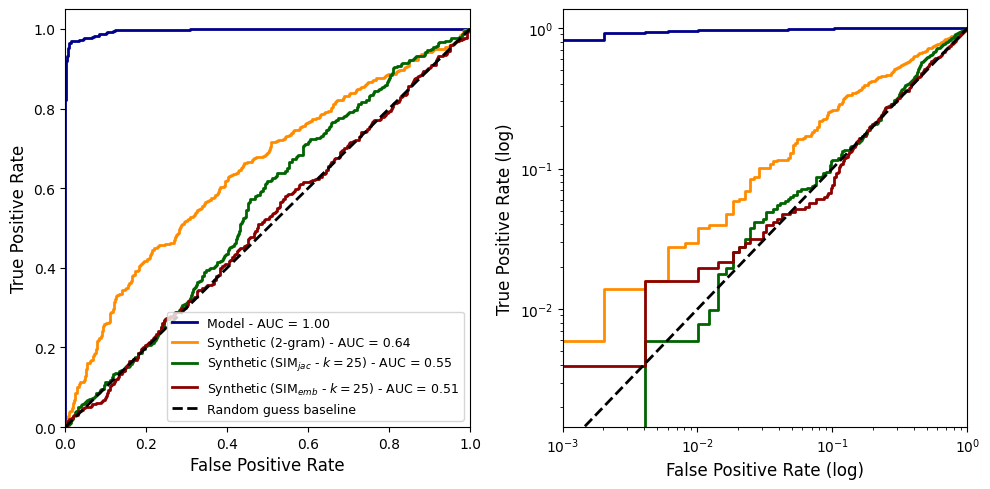

In [37]:
colors = ['darkblue', 'darkorange', 'darkgreen', 'darkred']

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

for i, key in enumerate(agnews_main_urls.keys()):
    performance = main_mia_results[key]
    fpr, tpr = performance['fpr'], performance['tpr']

    axes[0].plot(fpr, tpr, lw=2, label=f'{job_names[i]} - AUC = %0.2f' % performance['auc'], color = colors[i])
    axes[1].plot(fpr, tpr, lw=2, label=f'{job_names[i]} - AUC = %0.2f' % performance['auc'], color=colors[i])

axes[0].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')
axes[1].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize = 12)
axes[0].set_ylabel('True Positive Rate', fontsize = 12)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim([1e-3, 1e0])
axes[1].set_xlabel('False Positive Rate (log)', fontsize = 12)
axes[1].set_ylabel('True Positive Rate (log)', fontsize = 12)

axes[0].legend(loc="lower right", fontsize = 9)

plt.tight_layout()
plt.savefig('figures/tpr_fpr_all_attacks_agnews_syntheticcanary_uniformlabel.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [38]:
# do the same for sst-2

sst2_main_urls = {
    'model': 'https://ml.azure.com/runs/gentle_tail_0bfkrfjv50?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'synthetic_2gram': 'https://ml.azure.com/runs/quirky_battery_tvw7wcm4wh?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47', 
    'synthetic_jaccard25': 'https://ml.azure.com/runs/polite_vulture_66jf4synlb?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47', 
    'synthetic_embedding25': 'https://ml.azure.com/runs/tidy_shelf_q5r6tfffyp?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47'}

In [39]:
main_mia_results = {}

for key in sst2_main_urls.keys():
    main_mia_results[key] = compute_performance_from_url(sst2_main_urls[key])

AUC: 0.9986597373085124, TPR@0.01: 0.9723865877712031, TPR@0.05: 0.9940828402366864, TPR@0.1: 0.9960552268244576
AUC: 0.6163848114230388, TPR@0.01: 0.03155818540433925, TPR@0.05: 0.10453648915187377, TPR@0.1: 0.20907297830374755
AUC: 0.5473552816352005, TPR@0.01: 0.01775147928994083, TPR@0.05: 0.0670611439842209, TPR@0.1: 0.11439842209072978
AUC: 0.5295477913671081, TPR@0.01: 0.023668639053254437, TPR@0.05: 0.06903353057199212, TPR@0.1: 0.1282051282051282


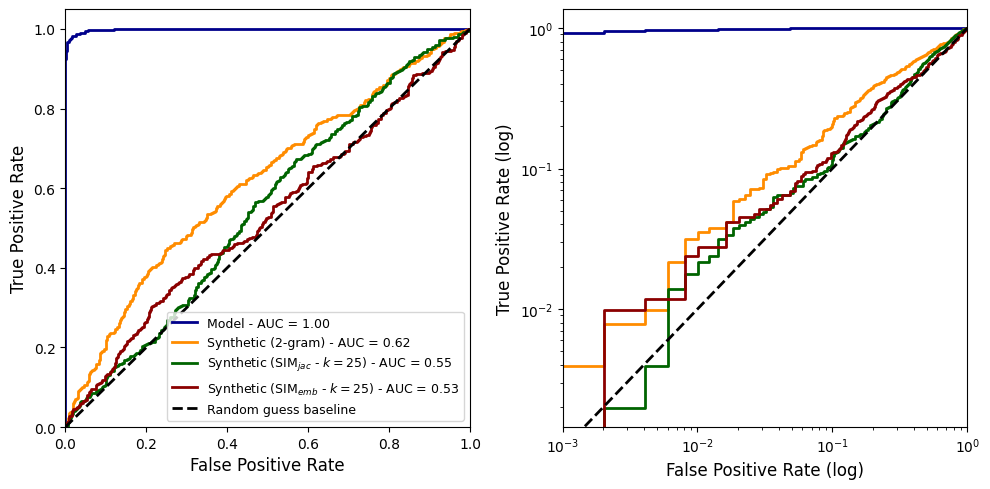

In [41]:
colors = ['darkblue', 'darkorange', 'darkgreen', 'darkred']

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

for i, key in enumerate(sst2_main_urls.keys()):
    performance = main_mia_results[key]
    fpr, tpr = performance['fpr'], performance['tpr']

    axes[0].plot(fpr, tpr, lw=2, label=f'{job_names[i]} - AUC = %0.2f' % performance['auc'], color = colors[i])
    axes[1].plot(fpr, tpr, lw=2, label=f'{job_names[i]} - AUC = %0.2f' % performance['auc'], color=colors[i])

axes[0].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')
axes[1].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize = 12)
axes[0].set_ylabel('True Positive Rate', fontsize = 12)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim([1e-3, 1e0])
axes[1].set_xlabel('False Positive Rate (log)', fontsize = 12)
axes[1].set_ylabel('True Positive Rate (log)', fontsize = 12)

axes[0].legend(loc="lower right", fontsize = 9)

plt.tight_layout()
plt.savefig('figures/tpr_fpr_all_attacks_sst2_syntheticcanary_uniformlabel.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()